# Section 1.2.3 — Files de Poisson indépendantes

Ce notebook sert de **référence analytique** pour le reste du projet. On considère deux files de premier niveau, $Q^+$ et $Q^-$, mais chacune évolue ici comme une file birth-death indépendante :

- les ajouts arrivent au taux constant $\lambda^+$ ;
- les retraits arrivent au taux constant $\lambda^-$ ;
- le temps d'atteinte est $\tau_0 = \inf\{t \ge 0 : Q(t)=0\}$.

L'objectif est de vérifier que la simulation reproduit le comportement attendu avant d'introduire les intensités auto-excitées de Hawkes dans le notebook suivant.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from model import IndependentPoissonSimulator, q1_depletion_problem
from model.restart_splitting import bootstrap_mean_ci
from model.plotting_utils import format_metric_table, plot_hist_with_ci
from model.utils import RNGStream, Timer

plt.rcParams.update({
    'figure.figsize': (10, 4.5),
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 100,
})

SEED = 123
Q0 = 10
LAMBDA_PLUS = 1.2
LAMBDA_MINUS = 1.5
N_RUNS = 3_000
T_MAX = 1_500.0
BOOTSTRAP_REPS = 1_000

pd.Series({
    'seed': SEED,
    'Q0': Q0,
    'lambda_plus': LAMBDA_PLUS,
    'lambda_minus': LAMBDA_MINUS,
    'n_runs': N_RUNS,
    'T_max': T_MAX,
}, name='configuration')

seed             123.0
Q0                10.0
lambda_plus        1.2
lambda_minus       1.5
n_runs          3000.0
T_max           1500.0
Name: configuration, dtype: float64

## Repère théorique

Pour une file birth-death avec $\lambda^- > \lambda^+$, le drift moyen est négatif :

$$
\mathbb{E}[Q(t)-Q(0)] = (\lambda^+ - \lambda^-)t.
$$

Le temps moyen d'atteinte de zéro vérifie alors le benchmark classique :

$$
\mathbb{E}[\tau_0 \mid Q(0)=q] = \frac{q}{\lambda^- - \lambda^+}.
$$

Ce résultat n'est pas une approximation numérique : il vient du problème de martingale associé au processus birth-death. La simulation Monte Carlo doit s'en approcher à l'intérieur de son erreur statistique.

In [2]:
def run_single_queue_poisson_mc(q0, lambda_plus, lambda_minus, n_runs, seed, T_max):
    simulator = IndependentPoissonSimulator(lambda_plus=lambda_plus, lambda_minus=lambda_minus)
    problem = q1_depletion_problem(T=T_max, q1_init=q0, queue_index=1, event_name='poisson_depletion')
    stream = RNGStream(seed)
    hitting_times = []
    sample_paths = []
    n_events = 0
    n_candidates = 0

    with Timer() as timer:
        for k in range(n_runs):
            traj = simulator.simulate(problem, rng=stream.next(), record_path=True)
            assert np.all(traj.states >= 0), 'Queue sizes must remain non-negative.'
            n_events += traj.n_events
            n_candidates += traj.n_candidates
            if traj.hit:
                hitting_times.append(float(traj.hitting_time))
            if k < 6:
                sample_paths.append(traj)

    hitting_times = np.asarray(hitting_times, dtype=float)
    return {
        'hitting_times': hitting_times,
        'sample_paths': sample_paths,
        'hit_rate': len(hitting_times) / n_runs,
        'n_events': n_events,
        'n_candidates': n_candidates,
        'acceptance_candidate_ratio': n_events / n_candidates if n_candidates else np.nan,
        'cpu_seconds': timer.elapsed,
    }

poisson_mc = run_single_queue_poisson_mc(Q0, LAMBDA_PLUS, LAMBDA_MINUS, N_RUNS, SEED, T_MAX)
tau = poisson_mc['hitting_times']
theoretical_mean_tau = Q0 / (LAMBDA_MINUS - LAMBDA_PLUS)
ci_low, ci_high = bootstrap_mean_ci(tau, n_bootstrap=BOOTSTRAP_REPS, rng=SEED + 1)

poisson_results = pd.DataFrame([{
    'q0': Q0,
    'lambda_plus': LAMBDA_PLUS,
    'lambda_minus': LAMBDA_MINUS,
    'theoretical_mean_tau': theoretical_mean_tau,
    'empirical_mean_tau': float(tau.mean()),
    'empirical_std': float(tau.std(ddof=1)),
    'bootstrap_ci_low': ci_low,
    'bootstrap_ci_high': ci_high,
    'relative_error': abs(tau.mean() - theoretical_mean_tau) / theoretical_mean_tau,
    'hit_rate': poisson_mc['hit_rate'],
    'n_runs': N_RUNS,
    'n_events': poisson_mc['n_events'],
    'n_candidates': poisson_mc['n_candidates'],
    'acceptance_candidate_ratio': poisson_mc['acceptance_candidate_ratio'],
    'cpu_seconds': poisson_mc['cpu_seconds'],
}])

assert LAMBDA_MINUS > LAMBDA_PLUS
assert poisson_mc['hit_rate'] == 1.0
assert ci_high >= ci_low
assert 0 <= poisson_mc['acceptance_candidate_ratio'] <= 1

display(format_metric_table(poisson_results, 3))

,q0,lambda_plus,lambda_minus,theoretical_mean_tau,empirical_mean_tau,empirical_std,bootstrap_ci_low,bootstrap_ci_high,relative_error,hit_rate,n_runs,n_events,n_candidates,acceptance_candidate_ratio,cpu_seconds
0,10,1.2,1.5,33.333,33.377,31.687,32.192,34.463,0.001,1.0,3000,270166,270166,1.0,4.475


In [3]:
rel = poisson_results.loc[0, 'relative_error']
inside_ci = poisson_results.loc[0, 'bootstrap_ci_low'] <= theoretical_mean_tau <= poisson_results.loc[0, 'bootstrap_ci_high']
display(Markdown(
    f"""
**Interprétation.** La moyenne empirique vaut {tau.mean():.2f}, contre un benchmark théorique de {theoretical_mean_tau:.2f}. 
L'erreur relative est {rel:.2%}. Le benchmark théorique {'appartient' if inside_ci else "n'appartient pas"} à l'intervalle bootstrap [{ci_low:.2f}, {ci_high:.2f}].
La variance reste importante parce que $\\tau_0$ dépend d'une succession aléatoire de retraits et d'ajouts; on valide donc le modèle de Poisson **dans l'incertitude Monte Carlo**, sans prétendre obtenir une valeur exacte par simulation.
"""
))


**Interprétation.** La moyenne empirique vaut 33.38, contre un benchmark théorique de 33.33. 
L'erreur relative est 0.13%. Le benchmark théorique appartient à l'intervalle bootstrap [32.19, 34.46].
La variance reste importante parce que $\tau_0$ dépend d'une succession aléatoire de retraits et d'ajouts; on valide donc le modèle de Poisson **dans l'incertitude Monte Carlo**, sans prétendre obtenir une valeur exacte par simulation.


## Trajectoires simulées

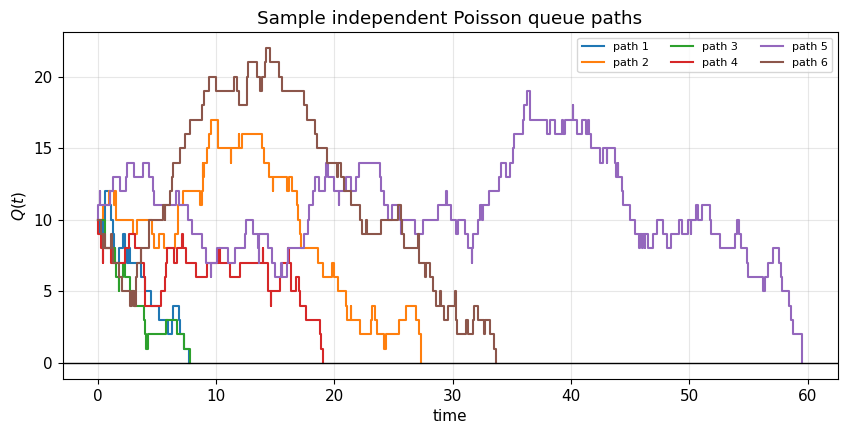

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for idx, traj in enumerate(poisson_mc['sample_paths']):
    ax.step(traj.times, traj.states[:, 0], where='post', linewidth=1.5, label=f'path {idx + 1}')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Sample independent Poisson queue paths')
ax.set_xlabel('time')
ax.set_ylabel(r'$Q(t)$')
ax.legend(ncol=3, fontsize=8)
plt.show()

**Lecture du graphique.** Les trajectoires descendent en moyenne parce que $\lambda^- > \lambda^+$. Les remontées locales restent possibles : elles correspondent aux ajouts Poisson. Cette variabilité explique pourquoi le temps d'atteinte a une dispersion non négligeable même dans un modèle très simple.

## Distribution des temps d'atteinte

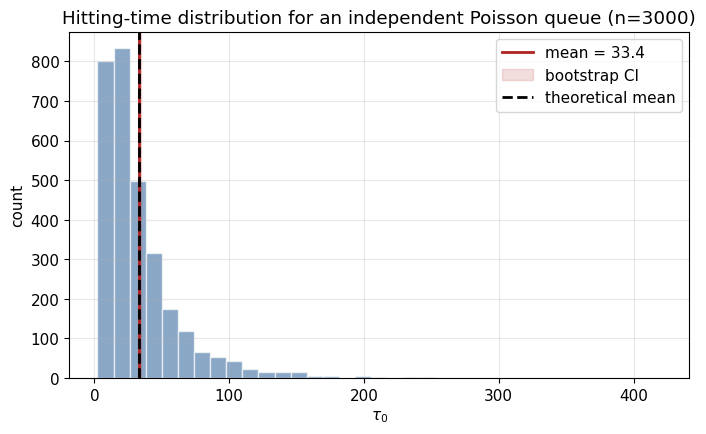

In [5]:
fig, ax = plot_hist_with_ci(
    tau,
    mean=float(tau.mean()),
    ci_low=ci_low,
    ci_high=ci_high,
    title=r'Hitting-time distribution for an independent Poisson queue',
    xlabel=r'$\tau_0$',
)
ax.axvline(theoretical_mean_tau, color='black', linestyle='--', linewidth=2, label='theoretical mean')
ax.legend()
plt.show()

**Interprétation.** L'histogramme est asymétrique à droite : certaines trajectoires reçoivent suffisamment d'ajouts pour retarder fortement la déplétion. La ligne théorique donne le centre attendu de la loi; l'intervalle bootstrap décrit seulement l'incertitude sur la moyenne, pas la dispersion complète de $	au_0$.

## Convergence Monte Carlo

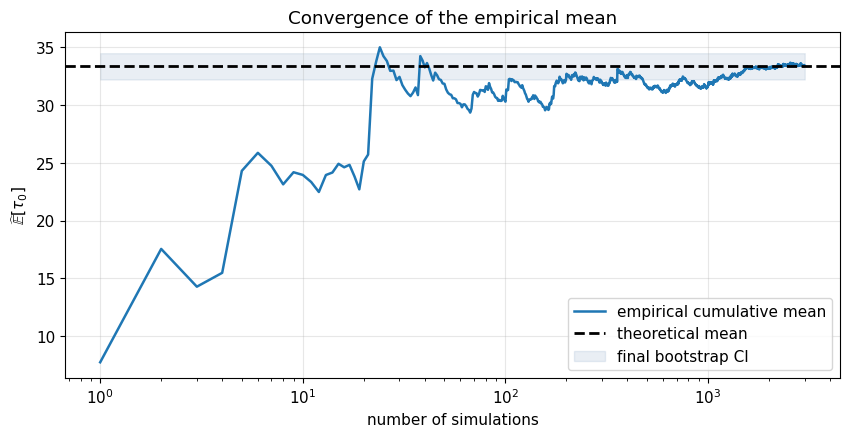

In [6]:
cumulative_mean = np.cumsum(tau) / np.arange(1, len(tau) + 1)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(np.arange(1, len(tau) + 1), cumulative_mean, linewidth=1.8, label='empirical cumulative mean')
ax.axhline(theoretical_mean_tau, color='black', linestyle='--', linewidth=2, label='theoretical mean')
ax.fill_between(np.arange(1, len(tau) + 1), ci_low, ci_high, color='#4C78A8', alpha=0.12, label='final bootstrap CI')
ax.set_xscale('log')
ax.set_title('Convergence of the empirical mean')
ax.set_xlabel('number of simulations')
ax.set_ylabel(r'$\widehat{\mathbb{E}}[\tau_0]$')
ax.legend()
plt.show()

**Interprétation.** La moyenne cumulée fluctue beaucoup au début, puis se stabilise lorsque le nombre de simulations augmente. Le graphique illustre le rôle du budget Monte Carlo : le modèle est analytique, mais l'estimateur empirique reste bruité pour un échantillon fini.

## Diagnostic pour deux files indépendantes

In [7]:
from model.hitting_times import batch_hitting_times

pair_mc = batch_hitting_times(
    n_runs=2_000,
    q1_init=Q0,
    q_neg1_init=Q0,
    lambda_plus=LAMBDA_PLUS,
    lambda_minus=LAMBDA_MINUS,
    seed=SEED + 20,
)
pair_table = pd.DataFrame([{
    'quantity': 'first depletion among Q+ and Q-',
    'mean_first_hit_time': pair_mc['mean_T'],
    'std_first_hit_time': pair_mc['std_T'],
    'ci_low': pair_mc['ci_95'][0],
    'ci_high': pair_mc['ci_95'][1],
    'prob_Q_plus_first': pair_mc['prob_q1_first'],
    'n_runs': pair_mc['n_runs'],
}])
display(format_metric_table(pair_table, 3))

,quantity,mean_first_hit_time,std_first_hit_time,ci_low,ci_high,prob_Q_plus_first,n_runs
0,first depletion among Q+ and Q-,18.548,12.805,17.987,19.109,0.5,2000


**Interprétation.** Avec deux files indépendantes et symétriques, la première déplétion est le minimum de deux temps d'atteinte; son espérance est donc inférieure à celle d'une file isolée. La probabilité que $Q^+$ touche zéro en premier reste proche de $1/2$, ce qui confirme la symétrie du benchmark.

## Synthèse nb1

In [8]:
summary_nb1 = pd.DataFrame([
    {
        'empirical_result': 'single-queue mean hitting time',
        'theoretical_expectation': f'{theoretical_mean_tau:.2f}',
        'observed_value': f'{tau.mean():.2f}',
        'matches_theory': bool(ci_low <= theoretical_mean_tau <= ci_high),
        'caveat': 'Monte Carlo uncertainty and right-skewed hitting times',
    },
    {
        'empirical_result': 'P(Q+ hits before Q-)',
        'theoretical_expectation': '0.50 by symmetry',
        'observed_value': f"{pair_mc['prob_q1_first']:.3f}",
        'matches_theory': abs(pair_mc['prob_q1_first'] - 0.5) < 0.03,
        'caveat': 'finite sample fluctuation',
    },
])
display(summary_nb1)

,empirical_result,theoretical_expectation,observed_value,matches_theory,caveat
0,single-queue mean hitting time,33.33,33.38,True,Monte Carlo uncertainty and right-skewed hitti...
1,P(Q+ hits before Q-),0.50 by symmetry,0.499,True,finite sample fluctuation


Le modèle de Poisson fournit une référence analytique, mais il ne capture pas le clustering empirique des événements de carnet. On introduit donc un modèle de Hawkes dans la section suivante.